<a href="https://colab.research.google.com/github/rSith/machine-learning-specialization/blob/main/ML_Specialization_02_Multiple_Variable_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mutiple Variable Linear Regression
> Expands on simple linear regression by adding more independent variables.

## Goals
> - Extend data structures to support multiple features
> - Rewrite prediction, cost and gradient routines to support multiple features
> - Utiliza NumPy `np.dot` to vectoriza their implementations for speed and simplicity

### Tools
- NumPy : for Scientific computing
- Matplotlib : for plotting data
- copy : Creates a shallow copy of an object
- math : Provides access to standard mathematical constants and functions

In [73]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)     #reduced display precision on numpy arrays

## Problem Statement
> **Housing price prediction**: The training dataset contains 3 examples with four features( size, bedroom, floors and, age )

In [74]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

### Matrix X contain Examples
Our examples(X values and Y values) are stored in a NumPy matrix X_train. Each row of the matrix represents one example.
> When we have $m$ training examples and there are $n$ features, $X$ is a matrix with dimensions $(m, n)$ *(in our problem $m=3$, $n=4$)*

Display the input data :

In [75]:
# data is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X  Type:{type(X_train)}")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)}")
print(y_train)

X Shape: (3, 4), X  Type:<class 'numpy.ndarray'>
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>
[460 232 178]


### Parameter vector w, b
> w is a vector with $n$ elements.
- Each element contains the parameter associated with one feature.
- in our dataset $n=4$

> b is a scalar parameter

For demonstration, $w$ and $b$ will be initial selected values that are near the optimal. $w$ is a 1-D NumPy vector

In [76]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


## Model Prediction With Multiple Variables
The model's prediction with multiple variables is given by the linear model:

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$
where $\cdot$ is a vector `dot product`

To demonstrate the dot product, we will implement prediction using (1) and (2).

### Single Prediction : element by element
> In simple linear regression we have multiplied one feature value by one parameter and added a bias parameter $w*x + b$.
> Previous implementation can use to multiple features to implement (1) above using **loop over each element, performing the multiply with its parameter** and then **adding the bias parameter at the end.**

In [77]:
def predict_single_loop(x, w, b):
  n = x.shape[0]
  p = 0
  for i in range(n):
    p_i = x[i] * w[i]
    p = p + p_i
  p = p + b
  return p

In [78]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

#make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


The shape of `x_vec` is a 1-D NumPy Vector with 4 elements. The result `f_wb` is a scalar

### Single Prediction : Using Vector
> We can use vector operations to speed up predictions using `np.dot()` it preform a vector dot product.

In [79]:
def predict(x, w, b):
  p = np.dot(x, w) + b
  return p

In [80]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


## Compute Cost with Multiple Variable
The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$


In contrast to previous, $\mathbf{w}$ and $\mathbf{x}^{(i)}$ are vectors rather than scalars supporting multiple features.

Implementation of equations :

In [81]:
def compute_cost(X, y, w, b):

  m = X.shape[0]
  cost = 0.0

  for i in range(m):
    f_wb_i = np.dot(X[i], w) + b
    cost = cost + (f_wb_i - y[i])**2
  cost = cost / (2 * m)

  return cost

In [82]:
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


## Gradient Descent with Multiple Variable

Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


### Compute Gradient with Multiple Variables
> To calculate the equations (6) and (7) there are many ways. In this version, we use :
- outer loop over all m examples.
    - $\frac{\partial J(\mathbf{w},b)}{\partial b}$ for the example can be computed directly and accumulated
- in a second loop over all n features:
    - $\frac{\partial J(\mathbf{w},b)}{\partial w_j}$ is computed for each $w_j$.
   

In [83]:
def compute_gradient(X, y, w, b):
  m, n = X.shape                   #(number of examples, number of features)
  dj_dw = np.zeros((n,))
  dj_db = 0.

  for i in range(m):
    err = (np.dot(X[i], w) + b - y[i])
    for j in range(n):
      dj_dw[j] = dj_dw[j] + err * X[i, j]
    dj_db = dj_db + err
  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_db, dj_dw


In [84]:
#Compute and display gradient
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: -1.6739251501955248e-06
dj_dw at initial w,b: 
 [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


## Gradient Descet with Multiple Variables


In [85]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):

  # An array to store cost J and w's at each iteration primarily for graphing later
  J_history = []
  w = copy.deepcopy(w_in) #avoid modifying gloabl w within function
  b = b_in

  for i in range(num_iters):

    # Calculate the gradient and update the parameters
    dj_db, dj_dw = gradient_function(X, y, w, b)

    # Update Prameters using w, b, alpha and gradient
    w = 2 - alpha * dj_dw
    b = b - alpha * dj_db

    # Save cost J at each iteration
    if i < 100000:   #prevent resource exhaustion
      J_history.append( cost_function(X, y, w, b))

    # Print cost every at intervals 10 times or as many iterations if < 10
    if i% math.ceil(num_iters / 10) == 0:
      print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}  ")

  return w, b, J_history #return w and J,w history for graphing

In [86]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 5.0e-7
# run gradient descent
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration    0: Cost 5242274.85  
Iteration  100: Cost 4491720836717544996864.00  
Iteration  200: Cost 10812566692446392671325489785418547200.00  
Iteration  300: Cost 26028243060934443986582884818640804543656525058539520.00  
Iteration  400: Cost 62655746420723451176637166981568271560923567872217763304949667594240.00  
Iteration  500: Cost 150826260164678876970173584281117686128733646419332472553124446203244301688028266496.00  
Iteration  600: Cost 363072216912242667599663466273607769096850082357986567683021146626352843426414151227341485320962048.00  
Iteration  700: Cost 873995248238881715578514493138404626608071294451900762019306611204844950767994486832846578193506126937526970089472.00  
Iteration  800: Cost 2103900156394451049643180904307223085075222843899805357648350192518616423617325546637888564545242546006415746831859243542078554112.00  
Iteration  900: Cost 5064553699800833725302611135366289291417743739103413281263296149283393716317550926153715216969654377630680907528807677225

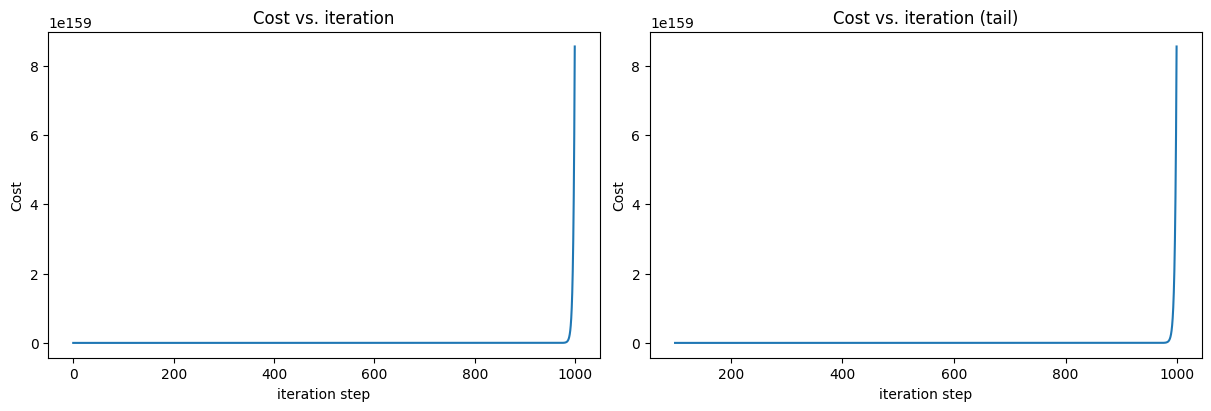

In [87]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step')
plt.show()

> *Cost is still declining and our predictions are not accutrate.*

# Feature scaling and Learning Rate (Multi-variable)

## Goals
- Utilize the multiple variables routines developed above
- run Gradient Descent on a data set with multiple features
- Explore the impact of the learning rate alpha on gradient descent
- Improve performance of gradient descent by feature scaling using z-score normalization


## Problem Statement
> **Housing price prediction**: The training dataset contains 3 examples with four features( size, bedroom, floors and, age )
- Note, In here the Size feature is in sqft while before utilized 1000 sqft.

Build a linear regression model using these values, so we can then predict the price for other houeses [1200 sqft, 3 bedrooms, 1 floor, 40 years old]

### Dataset:
| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|----------------------- |  
| 952             | 2                   | 1                | 65           | 271.5                  |  
| 1244            | 3                   | 2                | 64           | 232                    |  
| 1947            | 3                   | 2                | 17           | 509.8                  |  
| ...             | ...                 | ...              | ...          | ...                    |

In [88]:
X_train = np.array([[952, 2, 1, 65], [1244, 3, 2, 64], [1947, 3, 2, 17]])
y_train = np.array([271.5, 232, 509.8])

X_features = ['size(sqft)','bedrooms', 'floors', 'age']

Dataset and its features by plotting each feature verses price


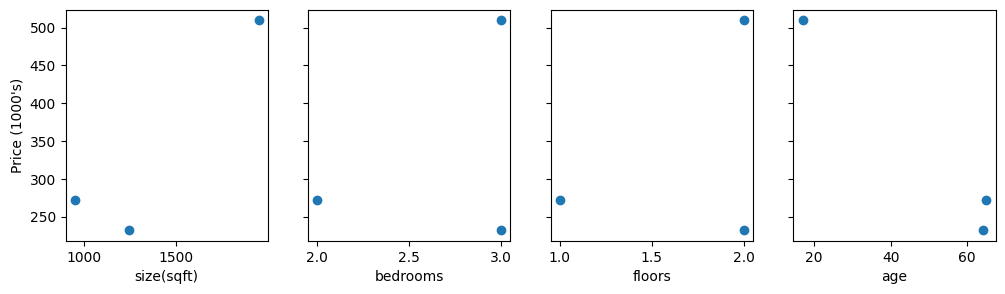

In [89]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

- Increasing size also increase price
- Bedrooms and floors don't seem to have a strong impcat on price.
- Newer houses have higher prices than older houses.


## Gradient Descent with Multiple Variables
>Is an iterative optimization algorithm used in machine learning to minimize a cost function when a model relies on multiple input features.

Equations of gradient descent for multiple variables.:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j = 0..n-1}\newline
&b\ \ := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{2}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{3}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


## Learning Rate $\alpha$
> The learning rate is a hyperparameter that controls the size of the steps a model takes during optimization to minimize the loss function.

- $\alpha$ too small: every step is tiny. It converges, but slowly.
- $\alpha$ too large: it overshoots the minimum, may never reach it, and can diverge (J grows).
- Fixed $\alpha$ is fine: near a minimum the derivative gets smaller, so $\alpha$ · dJ/dw gets smaller too. You don't need to shrink $\alpha$ by hand.
- At a local minimum the derivative is 0, so gradient descent stays there.

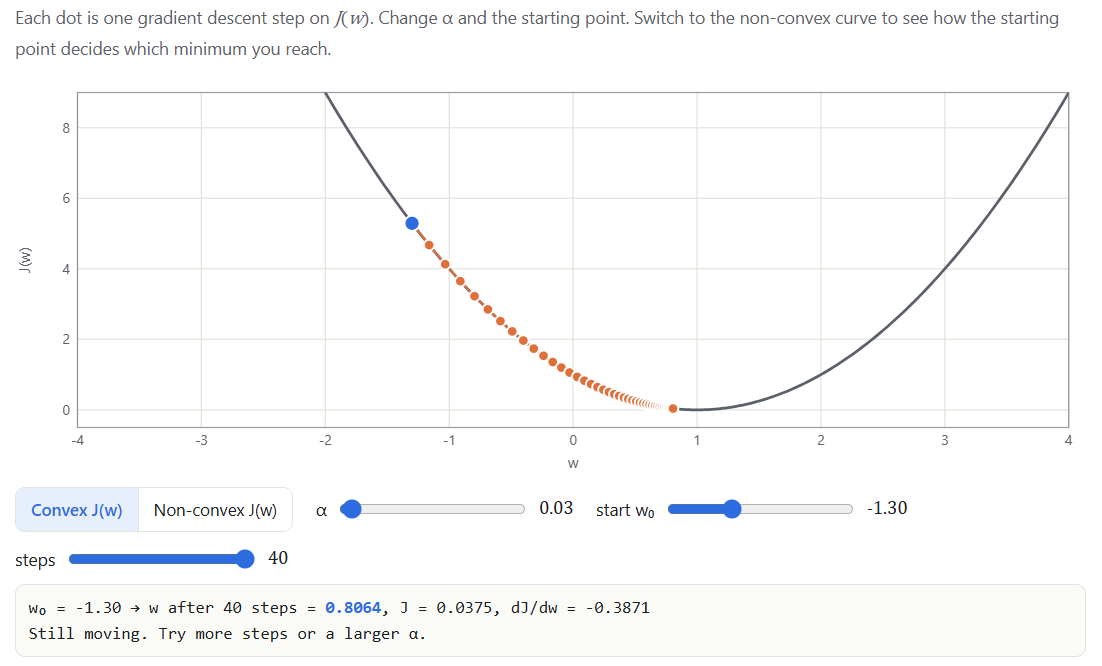

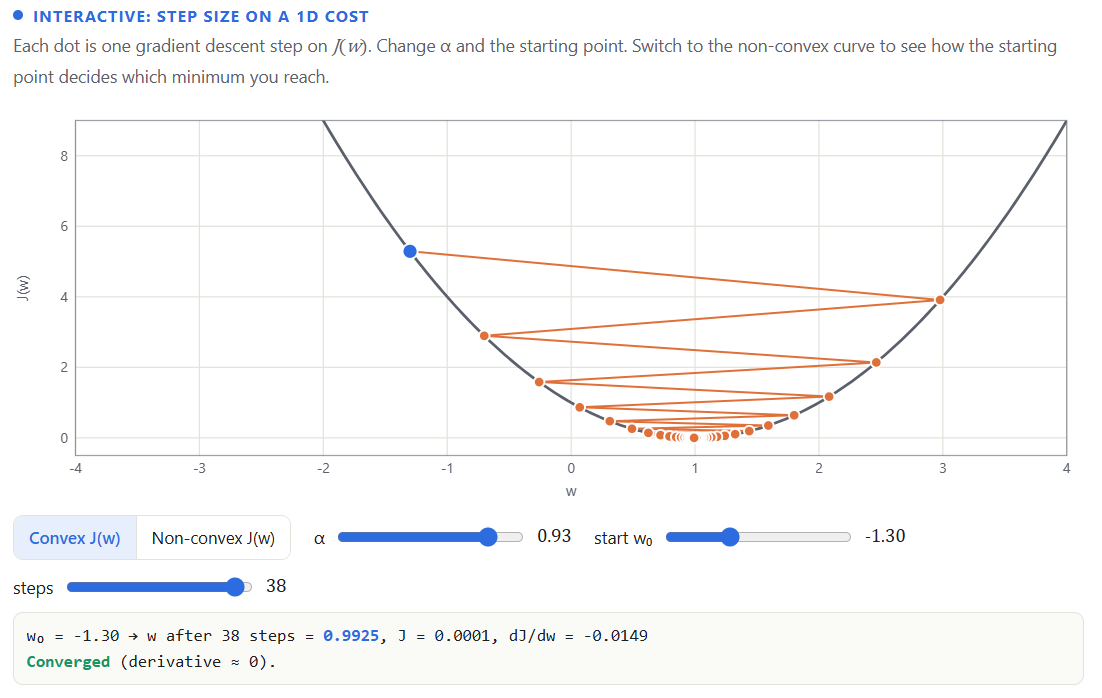

## Feature Scaling
> Data processing step used to bring all numerical variables or features in a dataset onto a similar scale

**Three Different techniques:**
- Dividing each positive feature by its maximum value or rescale each feature by both its minimum and maximum values using (x-min)/(max-min). Both ways normalizes features to the range of -1 and 1
- Mean Normalization: $x_i = \dfrac{x_i - \mu_i}{max - min} $
- Z-score normalization


### z-score normalization
After z-score normalization, all features will have a mean of 0 and a standard deviation of 1.

To implement z-score normalization, adjust your input values as shown in this formula:
$$x^{(i)}_j = \dfrac{x^{(i)}_j - \mu_j}{\sigma_j} \tag{4}$$
where $j$ selects a feature or a column in the $\mathbf{X}$ matrix. $µ_j$ is the mean of all the values for feature (j) and $\sigma_j$ is the standard deviation of feature (j).
$$
\begin{align}
\mu_j &= \frac{1}{m} \sum_{i=0}^{m-1} x^{(i)}_j \tag{5}\\
\sigma^2_j &= \frac{1}{m} \sum_{i=0}^{m-1} (x^{(i)}_j - \mu_j)^2  \tag{6}
\end{align}
$$

>**Implementation Note:** When normalizing the features, it is important
to store the values used for normalization - the mean value and the standard deviation used for the computations. After learning the parameters
from the model, we often want to predict the prices of houses we have not
seen before. Given a new x value (living room area and number of bed-
rooms), we must first normalize x using the mean and standard deviation
that we had previously computed from the training set.

**Implementation**

In [90]:
def zscore_normalize_features(X):
  # find the mean of each column/feature
  mu = np.mean(X, axis=0)
  # find the standard deviation of each column/feature
  sigma = np.std(X, axis=0)
  # element-wise, subtract mu for that column, from each example, divide by std for that column
  X_norm = (X - mu) / sigma

  return (X_norm, mu, sigma)


Steps involved in Z-score normalization. The plot below shows the transformation step by step:

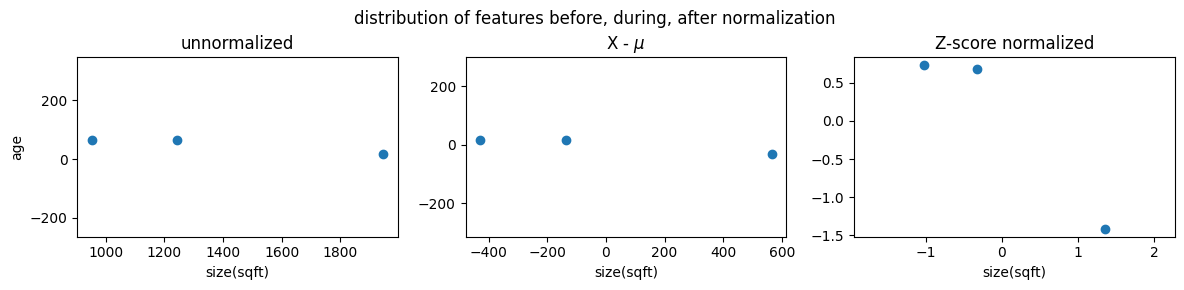

In [91]:
mu     = np.mean(X_train,axis=0)
sigma  = np.std(X_train,axis=0)
X_mean = (X_train - mu)
X_norm = (X_train - mu)/sigma

fig,ax=plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(X_train[:,0], X_train[:,3])
ax[0].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(X_mean[:,0], X_mean[:,3])
ax[1].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm[:,0], X_norm[:,3])
ax[2].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()

The plot above shows the relationship between two of the training set parameters, "age" and "size(sqft)". *These are plotted with equal scale*.
- Left: Unnormalized: The range of values or the variance of the 'size(sqft)' feature is much larger than that of age
- Middle: The first step removes the mean or average value from each feature. This leaves features that are centered around zero. It's difficult to see the difference for the 'age' feature, but 'size(sqft)' is clearly around zero.
- Right: The second step divides by the standard deviation. This leaves both features centered at zero with a similar scale.

Normalize the data and compare it to the original data.

In [92]:
# normalize the original features
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

X_mu = [1381.      2.67    1.67   48.67], 
X_sigma = [417.6    0.47   0.47  22.4 ]
Peak to Peak range by column in Raw        X:[995   1   1  48]
Peak to Peak range by column in Normalized X:[2.38 2.12 2.12 2.14]


The peak to peak range of each column is reduced from a factor of thousands to a factor of 2-3 by normalization

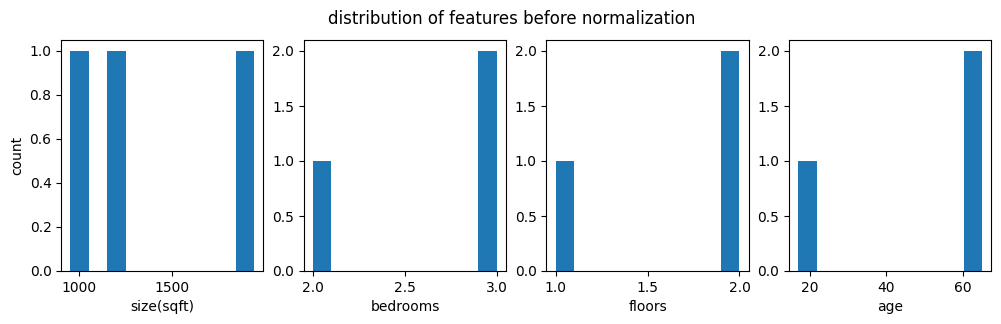

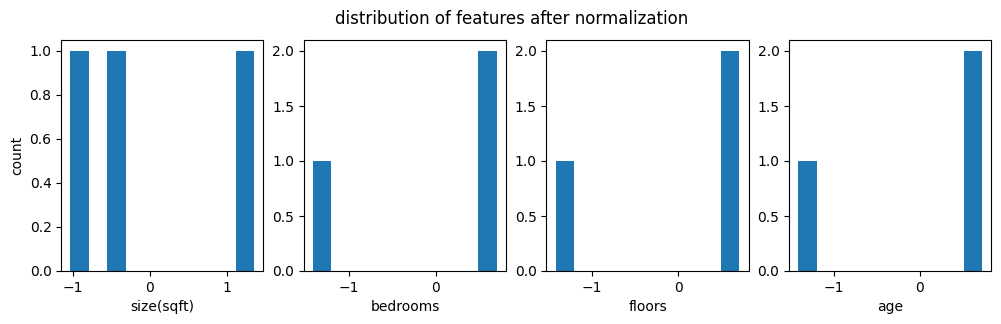

In [94]:
def norm_plot(ax, data):
    ax.hist(data)

fig,ax=plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    norm_plot(ax[i],X_train[:,i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count");
fig.suptitle("distribution of features before normalization")
plt.show()
fig,ax=plt.subplots(1,4,figsize=(12,3))
for i in range(len(ax)):
    norm_plot(ax[i],X_norm[:,i],)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count");
fig.suptitle("distribution of features after normalization")

plt.show()

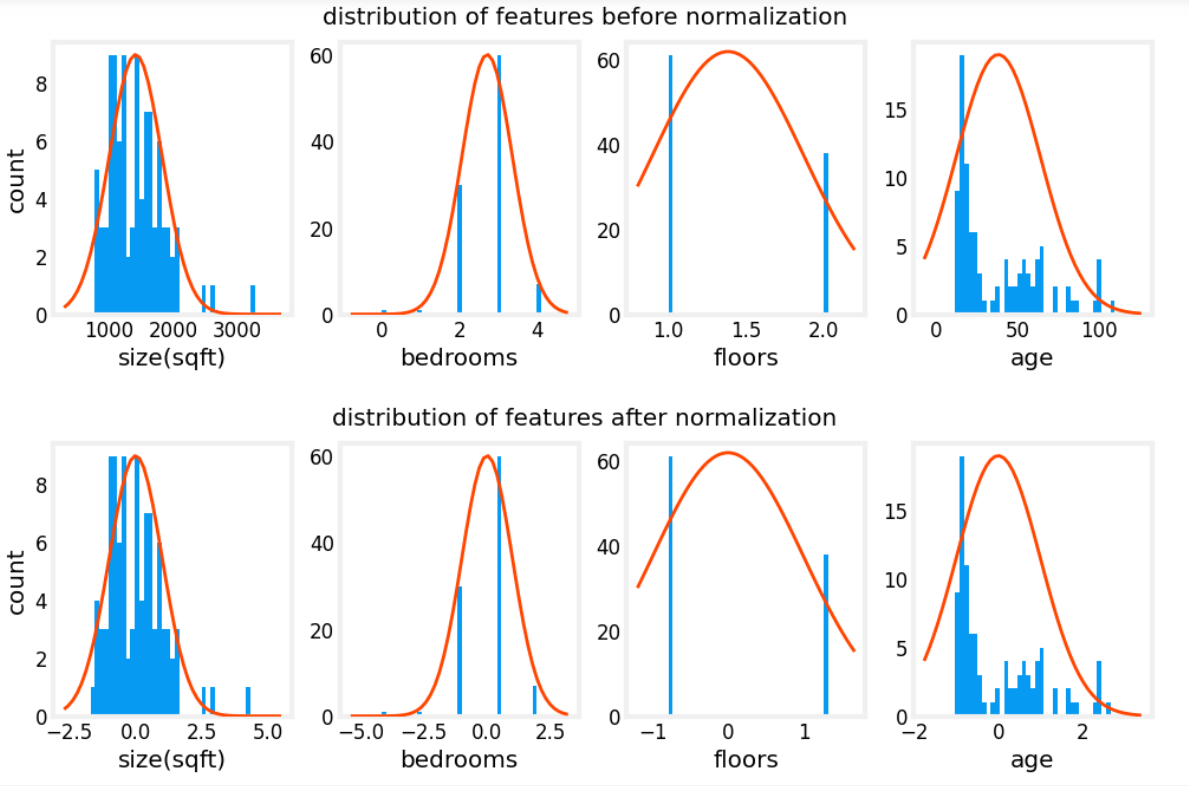

The range of the normalized data(x-axis) is centered around the zero and roughly +/-2. Most importantly the range is similar for each feature.

In [99]:
w_norm, b_norm, hist = gradient_descent(X_norm, y_train, initial_w_norm, initial_b_norm, compute_cost, compute_gradient, 1.0e-1, iterations)

Iteration    0: Cost 50954.63  
Iteration  100: Cost  5267.99  
Iteration  200: Cost  5267.99  
Iteration  300: Cost  5267.99  
Iteration  400: Cost  5267.99  
Iteration  500: Cost  5267.99  
Iteration  600: Cost  5267.99  
Iteration  700: Cost  5267.99  
Iteration  800: Cost  5267.99  
Iteration  900: Cost  5267.99  


The scaled features get very accurate results much faster

Iteration    0: Cost 50954.63  
Iteration  100: Cost  5267.99  
Iteration  200: Cost  5267.99  
Iteration  300: Cost  5267.99  
Iteration  400: Cost  5267.99  
Iteration  500: Cost  5267.99  
Iteration  600: Cost  5267.99  
Iteration  700: Cost  5267.99  
Iteration  800: Cost  5267.99  
Iteration  900: Cost  5267.99  


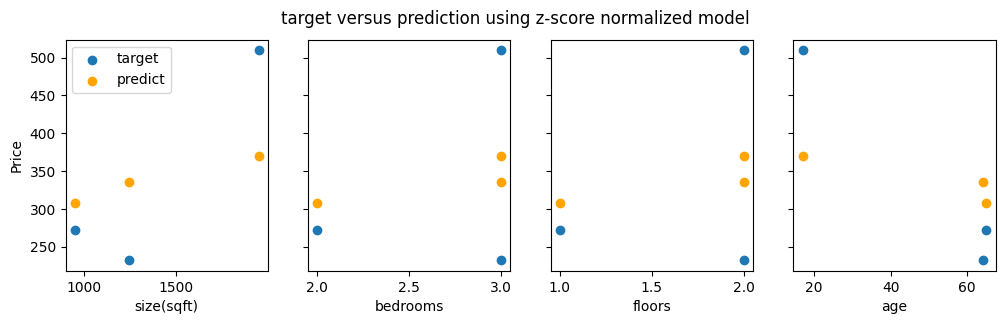

In [97]:
#predict target using normalized features
m = X_norm.shape[0]

# Initialize parameters for normalized data
initial_w_norm = np.zeros(X_norm.shape[1])
initial_b_norm = 0.

# Choose a suitable learning rate for normalized data
alpha_norm = 1.0e-1 # Larger alpha is often suitable for normalized features

# Run gradient descent on normalized features
w_norm, b_norm, J_hist_norm = gradient_descent(X_norm, y_train, initial_w_norm, initial_b_norm,
                                               compute_cost, compute_gradient,
                                               alpha_norm, iterations)

yp = np.zeros(m)
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm

    # plot predictions and targets versus original features
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],yp,color='orange', label = 'predict') # Replaced dlc with 'orange'
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

The results look good. A few points to note:
- with multiple features, we can no longer have a single plot showing results versus features.
- when generating the plot, the normalized features were used. Any predictions using the parameters learned from a normalized training set must also be normalized.

**Prediction**

The point of generating our model is to use it to predict housing prices that are not in the data set. Let's predict the price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old. Recall, that you must normalize the data with the mean and standard deviation derived when the training data was normalized.

In [100]:
# First, normalize out example.
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
x_house_predict = np.dot(x_house_norm, w_norm) + b_norm
print(f" predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = ${x_house_predict*1000:0.0f}")

[-0.43  0.71 -1.41 -0.39]
 predicted price of a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old = $332919
